## 3. CPI Target Inspection

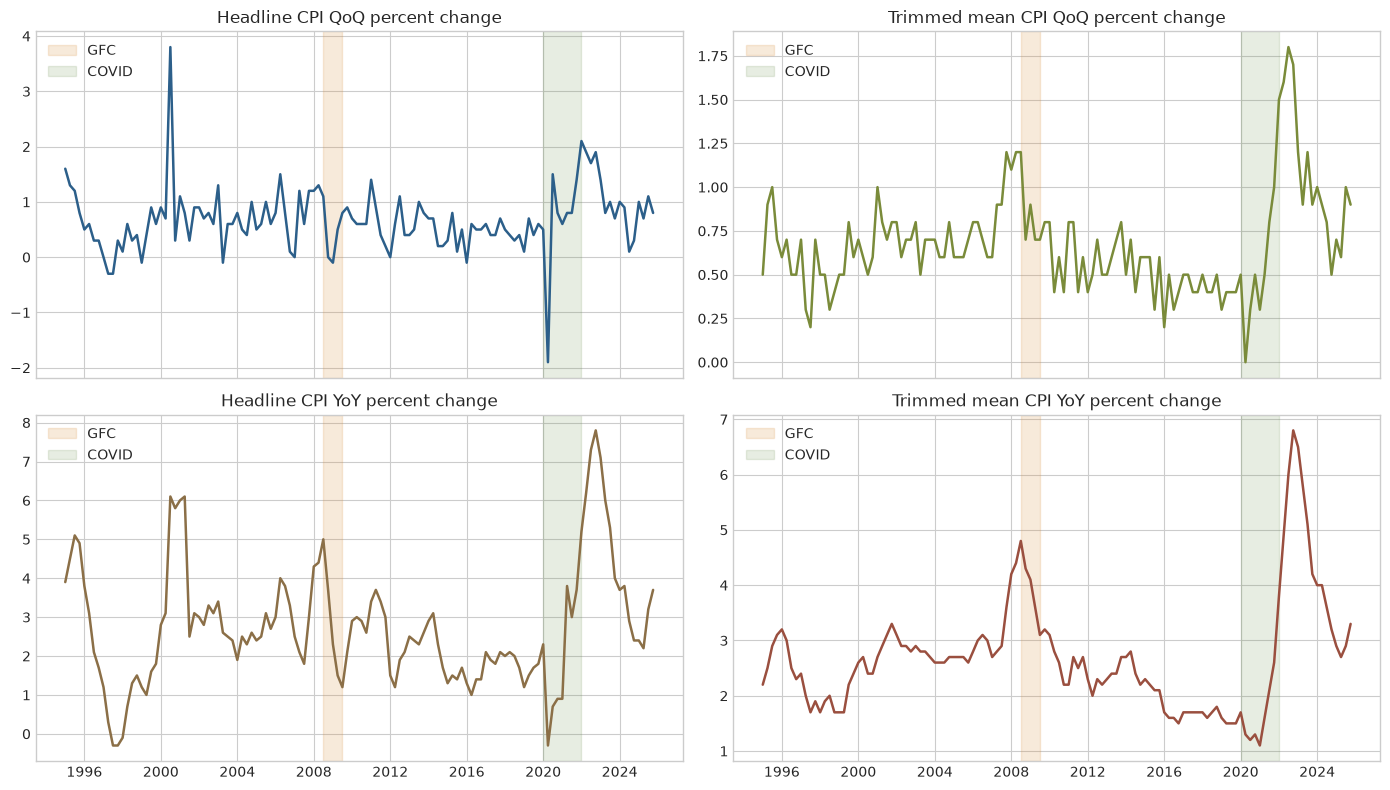

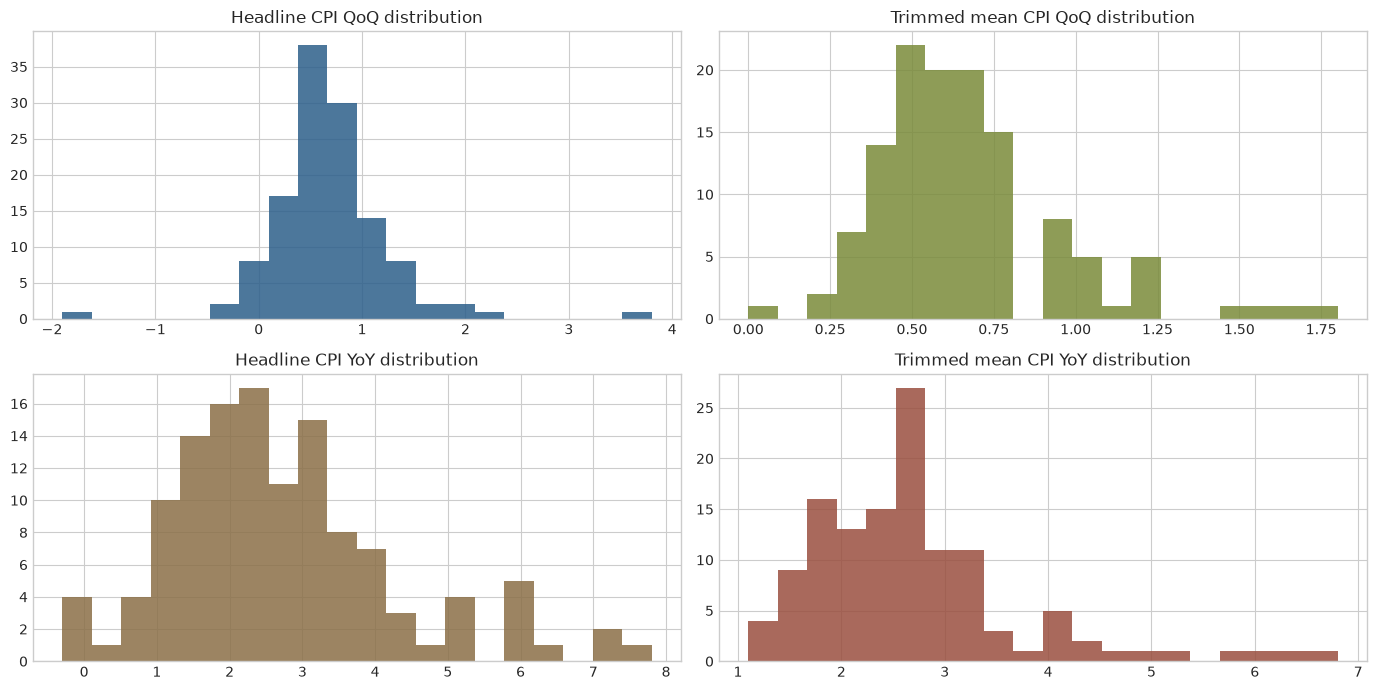

,quarter,metric,value,z_score
0,2000Q3,cpi_qoq,3.8,5.41
1,2020Q2,cpi_qoq,-1.9,-4.45
2,2022Q1,trimmed_mean_cpi_qoq,1.5,2.88
3,2022Q2,trimmed_mean_cpi_qoq,1.6,3.23
4,2022Q3,trimmed_mean_cpi_qoq,1.8,3.92
5,2022Q4,trimmed_mean_cpi_qoq,1.7,3.57
6,2022Q3,cpi_yoy,7.3,2.96
7,2022Q4,cpi_yoy,7.8,3.28
8,2023Q1,cpi_yoy,7.1,2.83
9,2022Q3,trimmed_mean_cpi_yoy,6.0,3.23


In [4]:
plot_specs = [
    ('cpi_qoq', 'Headline CPI QoQ percent change', '#2c5f8a'),
    ('trimmed_mean_cpi_qoq', 'Trimmed mean CPI QoQ percent change', '#7a8b3a'),
    ('cpi_yoy', 'Headline CPI YoY percent change', '#8b6f47'),
    ('trimmed_mean_cpi_yoy', 'Trimmed mean CPI YoY percent change', '#9a4f3f'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.reshape(-1)
for ax, (column, title, color) in zip(axes, plot_specs):
    ax.plot(df['quarter_start'], df[column], color=color, linewidth=1.8)
    ax.set_title(title)
    ax.axvspan(pd.Period('2008Q3', freq='Q').to_timestamp(), pd.Period('2009Q3', freq='Q').to_timestamp(), color='#d88c36', alpha=0.18, label='GFC')
    ax.axvspan(pd.Period('2020Q1', freq='Q').to_timestamp(), pd.Period('2022Q1', freq='Q').to_timestamp(), color='#6a8f4e', alpha=0.16, label='COVID')
    ax.legend(loc='best')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.reshape(-1)
for ax, (column, title, color) in zip(axes, plot_specs):
    df[column].dropna().hist(ax=ax, bins=20, color=color, alpha=0.85)
    ax.set_title(title.replace('percent change', 'distribution'))
fig.tight_layout()
plt.show()

outlier_rows = []
for column, _, _ in plot_specs:
    series = df[column]
    z_score = (series - series.mean()) / series.std(ddof=0)
    flagged = df.loc[z_score.abs() >= 2.5, ['quarter', column]].copy()
    flagged['metric'] = column
    flagged['z_score'] = z_score.loc[flagged.index].round(2)
    outlier_rows.append(flagged[['quarter', 'metric', column, 'z_score']].rename(columns={column: 'value'}))
outliers = pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame()
display(outliers)

### CPI Seasonal Decomposition And Autocorrelation Diagnostics

These diagnostics extend the CPI target inspection. STL separates the CPI index into trend, quarterly seasonal, and residual components; ACF/PACF plots then show whether CPI inflation and differenced CPI retain serial dependence that later SARIMA order selection should consider.

The modelling target `cpi_yoy` is already a four-quarter transformation: `CPI_YoY_t = (CPI_t / CPI_{t-4} - 1) * 100`. Adjacent YoY observations share overlapping CPI observations, so persistence in the ACF is partly mechanical and should not be interpreted as purely an autoregressive economic mechanism. Quarterly data also does not automatically imply `D = 1`; seasonal and non-seasonal SARIMA specifications should be compared with rolling-origin validation.

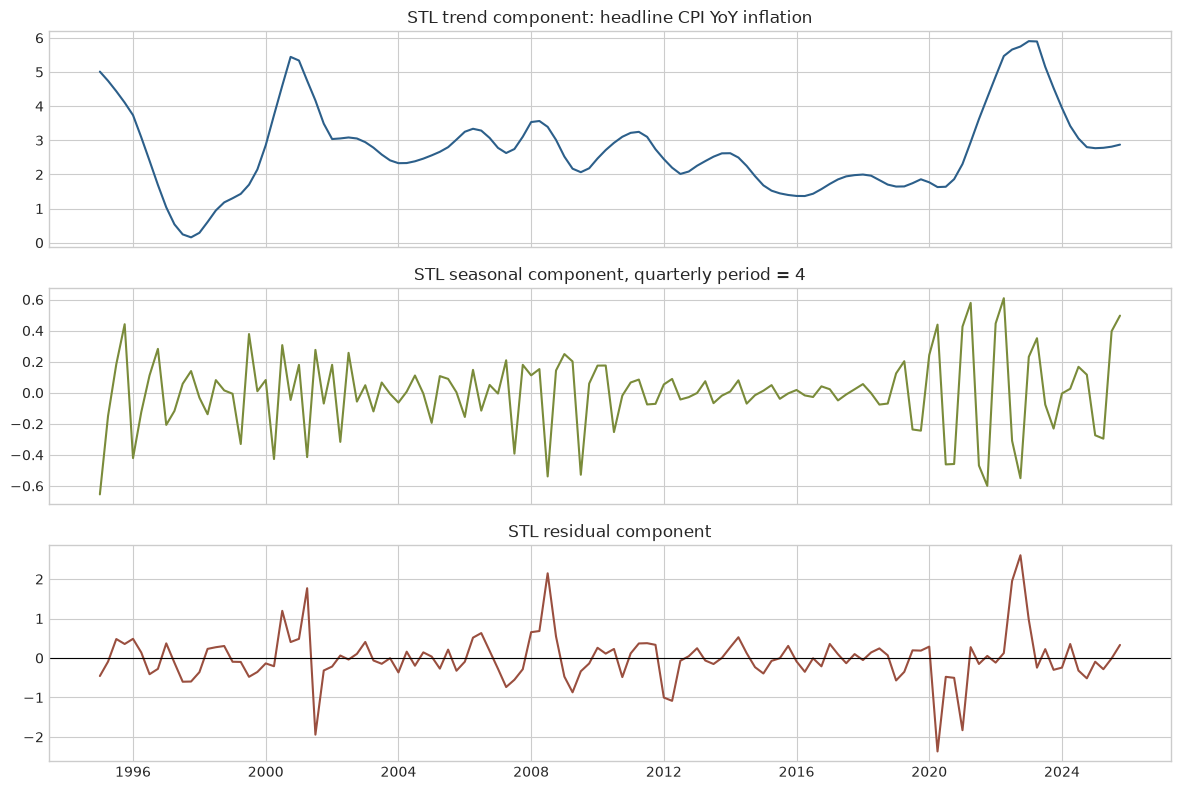

,series,stl_period_quarters,seasonal_strength,trend_strength,n_obs,interpretation
0,cpi_yoy,4,0.000,0.842,124,STL now decomposes the ABS SA headline growth-...
1,cpi_qoq,4,0.000,0.309,124,QoQ seasonality is closer to the quarterly inf...
2,trimmed_mean_cpi_yoy,4,0.000,0.875,124,Trimmed-mean YoY decomposition checks whether ...
3,trimmed_mean_cpi_qoq,4,0.063,0.704,124,QoQ seasonality is closer to the quarterly inf...


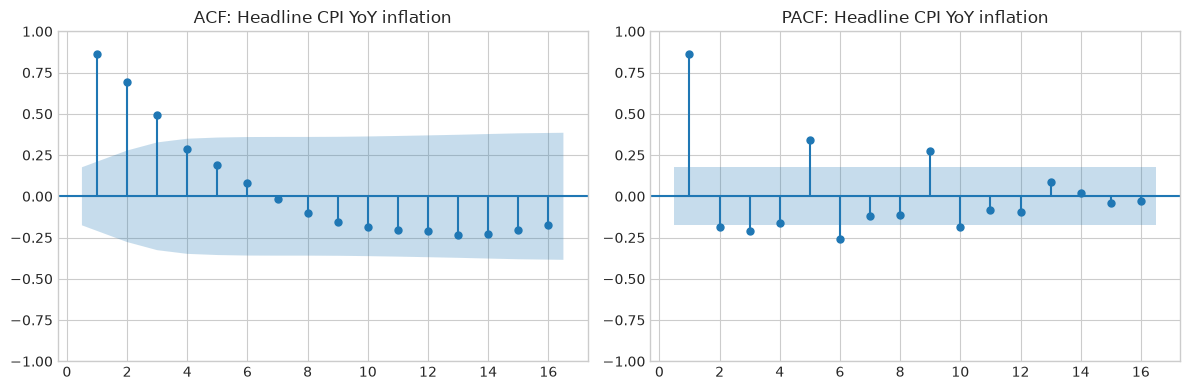

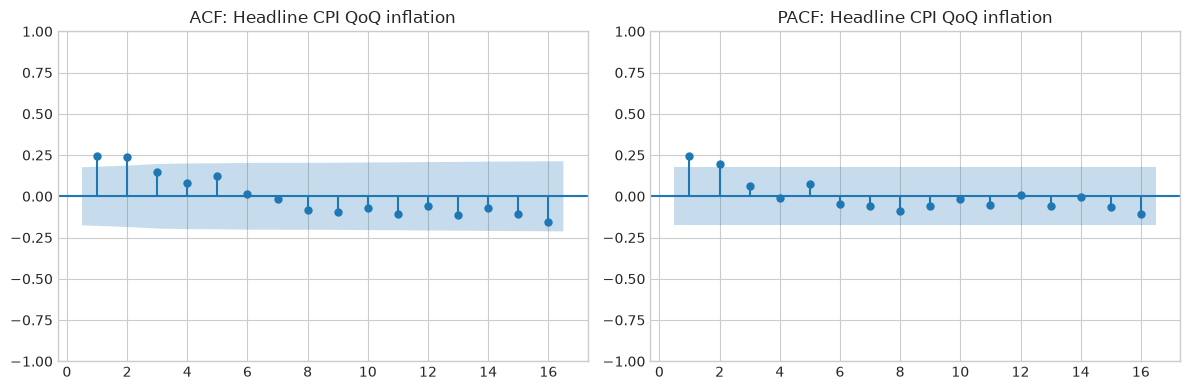

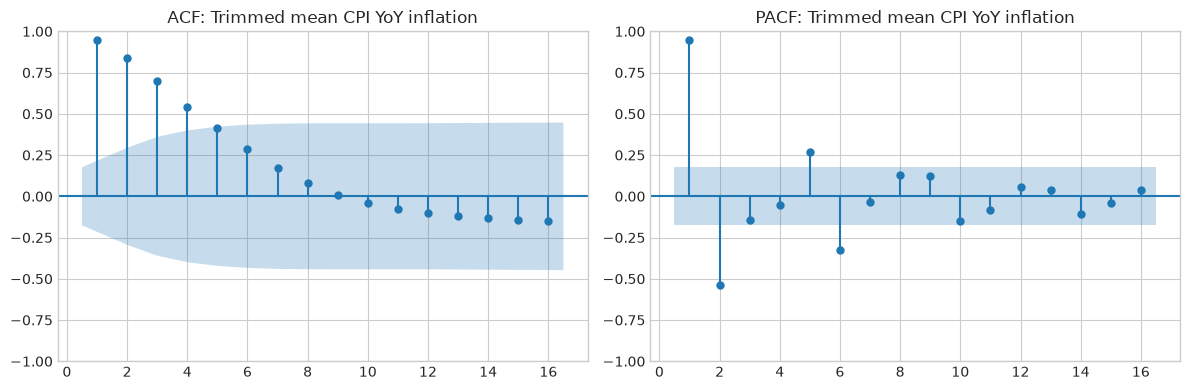

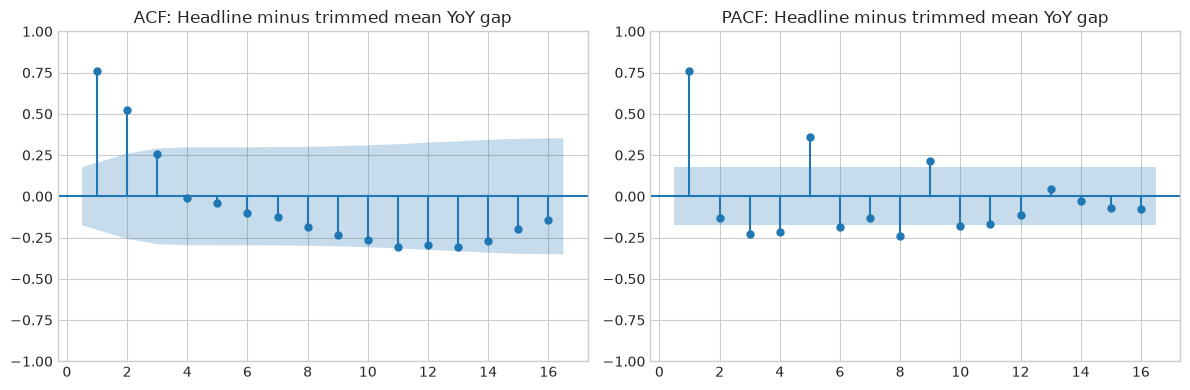

The STL decomposition now runs on headline CPI YoY inflation because `cpi_index` is no longer part of the curated ETL output. This is a growth-rate decomposition, not the prior level-series decomposition, so seasonal and trend strengths should be interpreted as properties of inflation rates. ACF/PACF patterns remain visual order-selection aids only; formal model choice still belongs to rolling-origin evaluation.

In [5]:
def stl_strength_summary(series: pd.Series, label: str) -> dict[str, object]:
    cleaned = series.dropna()
    result = STL(cleaned, period=4, robust=True).fit()
    seasonal_strength = max(0, 1 - np.nanvar(result.resid) / np.nanvar(result.resid + result.seasonal))
    trend_strength = max(0, 1 - np.nanvar(result.resid) / np.nanvar(result.resid + result.trend))
    return {
        'series': label,
        'stl_period_quarters': 4,
        'seasonal_strength': seasonal_strength,
        'trend_strength': trend_strength,
        'n_obs': int(len(cleaned)),
        'stl_result': result,
    }

cpi_stl_series = df.set_index('quarter_start')['cpi_yoy'].dropna()
stl_result = STL(cpi_stl_series, period=4, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(stl_result.trend.index, stl_result.trend, color='#2c5f8a')
axes[0].set_title('STL trend component: headline CPI YoY inflation')
axes[1].plot(stl_result.seasonal.index, stl_result.seasonal, color='#7a8b3a')
axes[1].set_title('STL seasonal component, quarterly period = 4')
axes[2].plot(stl_result.resid.index, stl_result.resid, color='#9a4f3f')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('STL residual component')
fig.tight_layout()
plt.show()

stl_strength_rows = [
    stl_strength_summary(df.set_index('quarter_start')[column], column)
    for column in ['cpi_yoy', 'cpi_qoq', 'trimmed_mean_cpi_yoy', 'trimmed_mean_cpi_qoq']
]
seasonality_summary = pd.DataFrame([
    {key: value for key, value in row.items() if key != 'stl_result'}
    for row in stl_strength_rows
])
seasonality_summary['interpretation'] = np.select(
    [
        seasonality_summary['series'].eq('cpi_yoy'),
        seasonality_summary['series'].eq('trimmed_mean_cpi_yoy'),
        seasonality_summary['series'].str.endswith('_qoq'),
    ],
    [
        'STL now decomposes the ABS SA headline growth-rate target, not a CPI level index.',
        'Trimmed-mean YoY decomposition checks whether underlying inflation has a different low-frequency profile.',
        'QoQ seasonality is closer to the quarterly inflation-rate series used in differenced SARIMA diagnostics.',
    ],
    default='',
)
display(seasonality_summary.round(3))

acf_pacf_series = {
    'Headline CPI YoY inflation': df.set_index('quarter_start')['cpi_yoy'].dropna(),
    'Headline CPI QoQ inflation': df.set_index('quarter_start')['cpi_qoq'].dropna(),
    'Trimmed mean CPI YoY inflation': df.set_index('quarter_start')['trimmed_mean_cpi_yoy'].dropna(),
    'Headline minus trimmed mean YoY gap': df.set_index('quarter_start')['headline_trimmed_mean_yoy_gap'].dropna(),
}

for title, series in acf_pacf_series.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    safe_lags = min(16, max(1, len(series) // 2 - 1))
    plot_acf(series, lags=safe_lags, ax=axes[0], zero=False)
    plot_pacf(series, lags=safe_lags, ax=axes[1], zero=False, method='ywm')
    axes[0].set_title(f'ACF: {title}')
    axes[1].set_title(f'PACF: {title}')
    fig.tight_layout()
    plt.show()

display(Markdown('The STL decomposition now runs on headline CPI YoY inflation because `cpi_index` is no longer part of the curated ETL output. This is a growth-rate decomposition, not the prior level-series decomposition, so seasonal and trend strengths should be interpreted as properties of inflation rates. ACF/PACF patterns remain visual order-selection aids only; formal model choice still belongs to rolling-origin evaluation.'))